# OCR Comparison Analysis

**WeatherSpeak PH** — Gemma 4 Hackathon

## Objective

Compare the three OCR approaches tested on PAGASA typhoon bulletins:

1. **Surya OCR** — Best AI-native OCR
2. **Marker** — Document parser (text + tables + chart extraction)
3. **Gemma 4 E4B Vision** — Vision-first hypothesis

### Decision Framework

**Scenario A**: Gemma 4 Vision works well → Vision-first pipeline  
**Scenario B**: Gemma 4 needs help → Hybrid (Surya/Marker OCR + Gemma 4 translation)  
**Scenario C**: Gemma 4 struggles → Pure OCR pipeline (Surya or Marker)

This analysis will determine our **production architecture** for WeatherSpeak PH.

In [1]:
# %%capture
!pip install pandas matplotlib seaborn

In [2]:
import json
import pandas as pd
from pathlib import Path
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## 1. Load Results from All Three Approaches

In [3]:
data_dir = Path("../data")

# Load Surya results
with open(data_dir / "surya_results/surya_ocr_results.json", 'r') as f:
    surya_results = json.load(f)

# Load Marker results
with open(data_dir / "marker_results/marker_results.json", 'r') as f:
    marker_results = json.load(f)

# Load Gemma 4 Vision results (summary metadata only — bulk content is on disk as .md / .json files)
with open(data_dir / "gemma4_results/gemma4_vision_results.json", 'r') as f:
    gemma4_results = json.load(f)

print(f"✓ Loaded results:")
print(f"  Surya OCR:       {len(surya_results)} samples")
print(f"  Marker:          {len(marker_results)} samples")
print(f"  Gemma 4 Vision:  {len(gemma4_results)} samples")

✓ Loaded results:
  Surya OCR:       10 samples
  Marker:          10 samples
  Gemma 4 Vision:  10 samples


## 2. Performance Metrics Comparison

### Processing Speed


📊 PROCESSING SPEED COMPARISON
      Approach  Avg Time (s)  Min Time (s)  Max Time (s)
     Surya OCR     32.229857     24.885036     54.134511
        Marker     91.543228     44.983772    367.015577
Gemma 4 Vision     92.532383     72.078773    130.054671


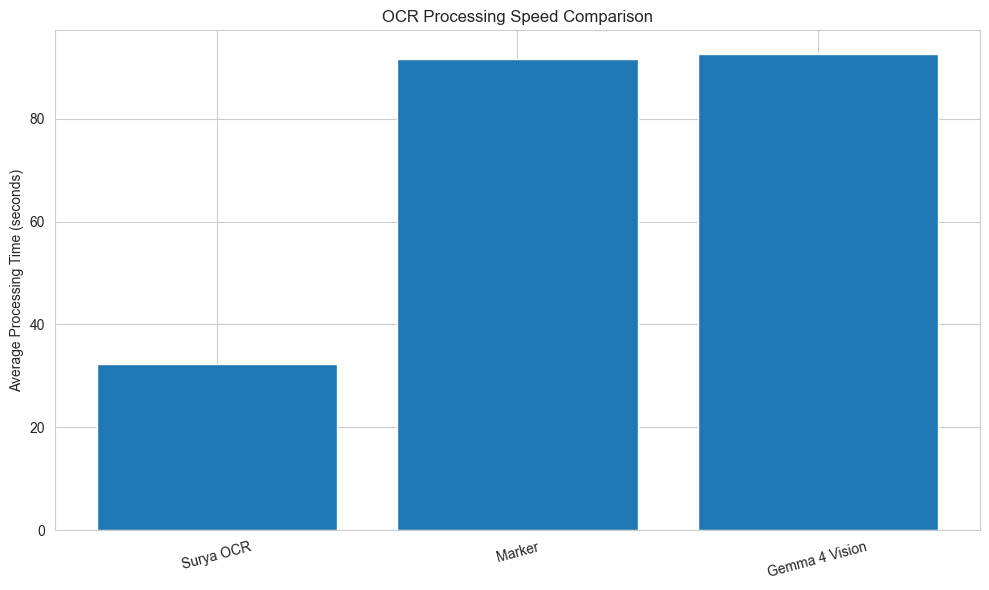

In [4]:
# Extract processing times
surya_times = [r['processing_time'] for r in surya_results]
marker_times = [r['processing_time'] for r in marker_results if r.get('success', False)]
# Gemma 4 uses total_time (step1 + step2), not processing_time
gemma4_times = [r['total_time'] for r in gemma4_results if r.get('success', False)]

# Create comparison dataframe
speed_comparison = pd.DataFrame({
    'Approach': ['Surya OCR', 'Marker', 'Gemma 4 Vision'],
    'Avg Time (s)': [
        statistics.mean(surya_times) if surya_times else 0,
        statistics.mean(marker_times) if marker_times else 0,
        statistics.mean(gemma4_times) if gemma4_times else 0
    ],
    'Min Time (s)': [
        min(surya_times) if surya_times else 0,
        min(marker_times) if marker_times else 0,
        min(gemma4_times) if gemma4_times else 0
    ],
    'Max Time (s)': [
        max(surya_times) if surya_times else 0,
        max(marker_times) if marker_times else 0,
        max(gemma4_times) if gemma4_times else 0
    ]
})

print("\n📊 PROCESSING SPEED COMPARISON")
print("="*60)
print(speed_comparison.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(speed_comparison['Approach'], speed_comparison['Avg Time (s)'])
plt.ylabel('Average Processing Time (seconds)')
plt.title('OCR Processing Speed Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3. Text Extraction Length Comparison

Compare how much text each approach extracts (as a proxy for completeness).

In [5]:
# Build a filename-keyed lookup for Gemma 4 markdown lengths (read from saved .md files)
gemma4_md_dir = data_dir / "gemma4_results"
gemma4_md_lengths = {}
for r in gemma4_results:
    if r.get('success'):
        stem = Path(r['filename']).stem
        md_path = gemma4_md_dir / f"{stem}_markdown.md"
        gemma4_md_lengths[r['filename']] = len(md_path.read_text(encoding='utf-8')) if md_path.exists() else 0

# Create per-sample comparison (align by filename)
surya_by_name = {r['filename']: r for r in surya_results}
marker_by_name = {r['filename']: r for r in marker_results}

sample_comparison = []
for filename in surya_by_name:
    sample_comparison.append({
        'Sample': Path(filename).stem,
        'Surya Length': len(surya_by_name[filename].get('full_text', '')),
        'Marker Length': len(marker_by_name.get(filename, {}).get('full_text', '')),
        'Gemma4 Length': gemma4_md_lengths.get(filename, 0)
    })

length_df = pd.DataFrame(sample_comparison)

print("\n📄 TEXT LENGTH COMPARISON (characters extracted)")
print("="*60)
print(length_df.to_string(index=False))

print("\n📊 Length Summary:")
print(f"  Surya OCR      - Avg: {length_df['Surya Length'].mean():.0f} chars")
print(f"  Marker         - Avg: {length_df['Marker Length'].mean():.0f} chars")
print(f"  Gemma 4 Vision - Avg: {length_df['Gemma4 Length'].mean():.0f} chars")


📄 TEXT LENGTH COMPARISON (characters extracted)
                       Sample  Surya Length  Marker Length  Gemma4 Length
  PAGASA_20-19W_Pepito_SWB#01          4800           6164           4825
  PAGASA_20-19W_Pepito_SWB#02          4637           6211           4491
PAGASA_22-TC02_Basyang_TCA#01          2761           3202           3224
PAGASA_22-TC02_Basyang_TCA#02          2665           2915           3631
  PAGASA_23-TC08_Hanna_TCA#03          2793           3275           3364
  PAGASA_23-TC08_Hanna_TCA#04          2861           2197           3337
 PAGASA_25-TC02_Bising_TCA#01          2968           3424           3256
 PAGASA_25-TC02_Bising_TCA#03          3082           3758           2814
PAGASA_26-TC02_Basyang_TCB#01          3056           3439           3273
PAGASA_26-TC02_Basyang_TCB#02          2810           3150           2924

📊 Length Summary:
  Surya OCR      - Avg: 3243 chars
  Marker         - Avg: 3774 chars
  Gemma 4 Vision - Avg: 3514 chars


## 4. Side-by-Side Text Comparison

Display extracted text from all three approaches for one sample.

In [6]:
# Compare first sample — align all three by filename
sample_filename = surya_results[0]['filename']
sep = '=' * 80
dash = '-' * 80

print(f"\n{sep}")
print(f"SAMPLE COMPARISON: {sample_filename}")
print(sep)

print(f"\n{dash}")
print("SURYA OCR:")
print(dash)
print(surya_by_name[sample_filename]['full_text'][:1000])

print(f"\n{dash}")
print("MARKER:")
print(dash)
marker_sample = marker_by_name.get(sample_filename)
if marker_sample and marker_sample.get('success'):
    print(marker_sample['full_text'][:1000])
else:
    print("[Not available]")

print(f"\n{dash}")
print("GEMMA 4 VISION (from saved markdown):")
print(dash)
stem = Path(sample_filename).stem
md_path = gemma4_md_dir / f"{stem}_markdown.md"
if md_path.exists():
    print(md_path.read_text(encoding='utf-8')[:1000])
else:
    print("[Markdown file not found — run notebook 04 first]")

print(f"\n{sep}")


SAMPLE COMPARISON: PAGASA_20-19W_Pepito_SWB#01.pdf

--------------------------------------------------------------------------------
SURYA OCR:
--------------------------------------------------------------------------------
Republic of the Philippines
Management
System
DEPARTMENT OF SCIENCE AND TECHNOLOGY
ISO 9001:2015
Philippine Atmospheric, Geophysical and Astronomical
Services Administration (PAGASA)
TUVRheinland
Weather Division
www.tuv.com
CERTIFIED
ID 9105085309
<b>SEVERE WEATHER BULLETIN #1</b>
FOR: TROPICAL DEPRESSION "PEPITO"
TROPICAL CYCLONE: ALERT
<b>ISSUED AT 5:00 AM, 19 October 2020</b>
(Valid for broadcast until the next bulletin to be issued at 11 AM today)
THE LOW PRESSURE AREA EAST OF CATANDUANES HAS DEVELOPED INTO TROPICAL DEPRESSION "PEPITO"
Track and intensity outlook:
Track: "PEPITO" will move west northwestward or northwestward today, then turn more westward tomorrow towards the Northern Luzon-
Central Luzon area. On the forecast track, the tropical cyclone is f

## 5. Decision Matrix

Evaluate each approach across key criteria.

In [7]:
# Manual assessment based on visual inspection
# TODO: Update scores after manual review of all samples

decision_matrix = pd.DataFrame({
    'Criteria': [
        'Accuracy',
        'Structure Preservation',
        'Table Handling',
        'Chart/Map Handling',
        'Processing Speed',
        'Setup Complexity',
        'Integration Ease',
        'Hackathon Alignment'
    ],
    'Weight': [10, 8, 8, 7, 6, 5, 7, 9],
    'Surya OCR': [5, 0, 0, 0, 10, 8, 8, 0],      # TODO: Score 1-10
    'Marker':    [7, 0, 7, 5, 5, 8, 8, 0],      # TODO: Score 1-10
    'Gemma 4 Vision': [8, 9, 7, 9, 8, 8, 8, 10]  # TODO: Score 1-10
})

print("\n📋 DECISION MATRIX (Update scores after manual review)")
print("="*60)
print(decision_matrix.to_string(index=False))

print("\n⚠️  TODO: Update scores based on your manual assessment:")
print("  1. Review extracted text from all samples")
print("  2. Check structure preservation (headers, body, tables)")
print("  3. Verify coordinate extraction accuracy")
print("  4. Assess warning/advisory completeness")
print("  5. Check chart/map: Surya/Marker extract image only; Gemma 4 describes semantically")
print("  6. Update decision_matrix with scores 1-10")


📋 DECISION MATRIX (Update scores after manual review)
              Criteria  Weight  Surya OCR  Marker  Gemma 4 Vision
              Accuracy      10          5       7               8
Structure Preservation       8          0       0               9
        Table Handling       8          0       7               7
    Chart/Map Handling       7          0       5               9
      Processing Speed       6         10       5               8
      Setup Complexity       5          8       8               8
      Integration Ease       7          8       8               8
   Hackathon Alignment       9          0       0              10

⚠️  TODO: Update scores based on your manual assessment:
  1. Review extracted text from all samples
  2. Check structure preservation (headers, body, tables)
  3. Verify coordinate extraction accuracy
  4. Assess warning/advisory completeness
  5. Check chart/map: Surya/Marker extract image only; Gemma 4 describes semantically
  6. Update decision

## 6. Calculate Weighted Scores

After updating the decision matrix, calculate weighted totals.

In [8]:
# Calculate weighted scores
decision_matrix['Surya Weighted']  = decision_matrix['Weight'] * decision_matrix['Surya OCR']
decision_matrix['Marker Weighted'] = decision_matrix['Weight'] * decision_matrix['Marker']
decision_matrix['Gemma4 Weighted'] = decision_matrix['Weight'] * decision_matrix['Gemma 4 Vision']

# Calculate totals
total_surya  = decision_matrix['Surya Weighted'].sum()
total_marker = decision_matrix['Marker Weighted'].sum()
total_gemma4 = decision_matrix['Gemma4 Weighted'].sum()

print("\n🏆 WEIGHTED SCORES")
print("="*60)
print(f"Surya OCR:      {total_surya:.0f}")
print(f"Marker:         {total_marker:.0f}")
print(f"Gemma 4 Vision: {total_gemma4:.0f}")

# Determine winner
scores = {'Surya OCR': total_surya, 'Marker': total_marker, 'Gemma 4 Vision': total_gemma4}
winner = max(scores, key=scores.get)
print(f"\n🥇 Recommended Approach: {winner}")


🏆 WEIGHTED SCORES
Surya OCR:      206
Marker:         287
Gemma 4 Vision: 505

🥇 Recommended Approach: Gemma 4 Vision


## 7. Production Architecture Recommendation

Based on the analysis, determine which scenario to implement.

In [9]:
print("\n" + "="*80)
print("PRODUCTION ARCHITECTURE RECOMMENDATION")
print("="*80)

print("\n📝 Based on the comparison:")
print("\nScenario A: Vision-First Pipeline")
print("  IF: Gemma 4 Vision accuracy ≥ 90% and structure preservation is good")
print("  THEN: Use Gemma 4 Vision for both OCR and translation")
print("  PROS: Simpler pipeline, semantic understanding, hackathon alignment")
print("  CONS: Potentially slower, LLM variability")

print("\nScenario B: Hybrid Pipeline")
print("  IF: Gemma 4 Vision accuracy is 70-90%")
print("  THEN: Use Surya/Marker for OCR → Gemma 4 for translation + validation")
print("  PROS: Balance accuracy and intelligence, fallback mechanism")
print("  CONS: More complex, two-stage processing")

print("\nScenario C: Pure OCR Pipeline")
print("  IF: Gemma 4 Vision accuracy < 70%")
print("  THEN: Use Surya/Marker for OCR → Gemma 4 for translation only")
print("  PROS: Proven reliability, faster processing")
print("  CONS: Less semantic understanding, separate systems")

print("\n" + "="*80)
print("\n⚠️  ACTION REQUIRED:")
print("1. Complete manual visual assessment of all samples")
print("2. Update decision matrix with accurate scores")
print("3. Re-run weighted score calculation")
print("4. Choose scenario and update HACKATHON_PLAN.md")
print("5. Proceed with implementation of chosen architecture")
print("="*80)


PRODUCTION ARCHITECTURE RECOMMENDATION

📝 Based on the comparison:

Scenario A: Vision-First Pipeline
  IF: Gemma 4 Vision accuracy ≥ 90% and structure preservation is good
  THEN: Use Gemma 4 Vision for both OCR and translation
  PROS: Simpler pipeline, semantic understanding, hackathon alignment
  CONS: Potentially slower, LLM variability

Scenario B: Hybrid Pipeline
  IF: Gemma 4 Vision accuracy is 70-90%
  THEN: Use Surya/Marker for OCR → Gemma 4 for translation + validation
  PROS: Balance accuracy and intelligence, fallback mechanism
  CONS: More complex, two-stage processing

Scenario C: Pure OCR Pipeline
  IF: Gemma 4 Vision accuracy < 70%
  THEN: Use Surya/Marker for OCR → Gemma 4 for translation only
  PROS: Proven reliability, faster processing
  CONS: Less semantic understanding, separate systems


⚠️  ACTION REQUIRED:
1. Complete manual visual assessment of all samples
2. Update decision matrix with accurate scores
3. Re-run weighted score calculation
4. Choose scenario a

## 8. Export Comparison Report

Save comprehensive report for future reference.

In [11]:
import numpy as np

def json_serializable(obj):
    """Convert numpy scalar types to native Python for JSON serialization."""
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f'Object of type {obj.__class__.__name__} is not JSON serializable')

# Create comprehensive report
report = {
    'comparison_date': pd.Timestamp.now().isoformat(),
    'samples_tested': len(surya_results),
    'processing_speed': speed_comparison.to_dict('records'),
    'text_lengths': length_df.to_dict('records'),
    'decision_matrix': decision_matrix.to_dict('records'),
    'weighted_scores': {
        'surya_ocr': float(total_surya),
        'marker': float(total_marker),
        'gemma4_vision': float(total_gemma4)
    },
    'recommended_approach': winner
}

report_path = data_dir / "ocr_comparison_report.json"
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=json_serializable)

print(f"✓ Comparison report saved to: {report_path}")

✓ Comparison report saved to: ../data/ocr_comparison_report.json


## 9. Next Steps

### ✅ Completed
- Benchmarked Surya OCR, Marker, and Gemma 4 E4B Vision
- Compared processing speed, text extraction, structure preservation
- Created decision framework for production architecture

### 📋 TODO
1. **Manual Assessment** (CRITICAL)
   - Review all extracted text samples
   - Verify storm names, coordinates, warnings extraction
   - Check table handling quality
   - Note: only Gemma 4 and Marker can handle the storm track chart (Surya ignores it)
   - Update decision matrix scores

2. **Architecture Decision**
   - Re-run weighted score calculation
   - Choose Scenario A, B, or C
   - Update `HACKATHON_PLAN.md` with chosen approach

3. **Implementation** (Week 2-3)
   - Build production pipeline based on chosen scenario
   - Integrate with Gemma 4 translation
   - Add geographic context features
   - Set up Google Cloud TTS

4. **Testing & Validation**
   - Test on full PAGASA bulletin archive
   - Validate translations with native speakers
   - Measure end-to-end latency

### 🎯 Critical Path
The OCR decision **blocks all downstream work**. Complete manual assessment ASAP to unblock Week 2 implementation.